# Temporal Churn Dataset Construction

## Customer Intelligence Analytics

This notebook constructs a point-in-time customer churn dataset from the
Online Retail II transaction history.

Because the source is transactional e-commerce data rather than a contractual
subscription service, churn is defined operationally as:

> A recently active customer who makes no valid purchase during the following
> 90 days.

### Design

- Features are calculated using only information available before each
  snapshot date.
- Customers must have purchased within the previous 180 days to be eligible.
- The prediction horizon is 90 days.
- Multiple historical snapshots are created to increase the training sample.
- Future transactions are used only to construct the target and are never
  included in predictive features.
- Full-dataset RFM segments and ML clusters are deliberately excluded because
  they contain information from dates after historical snapshots.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


CUSTOMER_SALES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_sales.parquet"
)

CUSTOMER_TRANSACTIONS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_transactions.parquet"
)

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "churn_snapshots.parquet"
)

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


PREDICTION_DAYS = 90
ELIGIBILITY_DAYS = 180
MIN_HISTORY_DAYS = 180


print(f"Customer sales:       {CUSTOMER_SALES_PATH}")
print(f"Customer activity:    {CUSTOMER_TRANSACTIONS_PATH}")
print(f"Prediction horizon:   {PREDICTION_DAYS} days")
print(f"Eligibility window:   {ELIGIBILITY_DAYS} days")

Customer sales:       c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_sales.parquet
Customer activity:    c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\customer_transactions.parquet
Prediction horizon:   90 days
Eligibility window:   180 days


In [3]:
customer_sales = pd.read_parquet(
    CUSTOMER_SALES_PATH
)

customer_transactions = pd.read_parquet(
    CUSTOMER_TRANSACTIONS_PATH
)


customer_sales["invoice_date"] = pd.to_datetime(
    customer_sales["invoice_date"]
)

customer_transactions["invoice_date"] = pd.to_datetime(
    customer_transactions["invoice_date"]
)


customer_sales["invoice_key"] = (
    customer_sales["source_period"].astype("string")
    + "::"
    + customer_sales["invoice"].astype("string")
)

customer_transactions["invoice_key"] = (
    customer_transactions["source_period"].astype("string")
    + "::"
    + customer_transactions["invoice"].astype("string")
)


print(f"Customer sales rows:        {len(customer_sales):,}")
print(f"Customer activity rows:     {len(customer_transactions):,}")

print(
    f"Purchasing customers:       "
    f"{customer_sales['customer_id'].nunique():,}"
)

print(
    f"Minimum date:               "
    f"{customer_sales['invoice_date'].min()}"
)

print(
    f"Maximum date:               "
    f"{customer_sales['invoice_date'].max()}"
)

Customer sales rows:        793,609
Customer activity rows:     812,368
Purchasing customers:       5,878
Minimum date:               2009-12-01 07:45:00
Maximum date:               2011-12-09 12:50:00


In [4]:
sales_orders = (
    customer_sales
    .groupby(
        [
            "customer_id",
            "invoice_key",
        ],
        observed=True,
    )
    .agg(
        invoice_date=("invoice_date", "min"),
        order_value=("line_amount", "sum"),
        order_units=("quantity", "sum"),
    )
    .reset_index()
)


activity_orders = (
    customer_transactions
    .groupby(
        [
            "customer_id",
            "invoice_key",
        ],
        observed=True,
    )
    .agg(
        invoice_date=("invoice_date", "min"),
        is_return_invoice=("is_return_or_reversal", "max"),
    )
    .reset_index()
)


print(f"Valid sales orders:      {len(sales_orders):,}")
print(f"All activity invoices:   {len(activity_orders):,}")

Valid sales orders:      37,745
All activity invoices:   45,777


In [5]:
data_start = (
    customer_sales["invoice_date"]
    .min()
    .normalize()
)

data_end = (
    customer_sales["invoice_date"]
    .max()
    .normalize()
)


minimum_snapshot_candidate = (
    data_start
    + pd.Timedelta(days=MIN_HISTORY_DAYS)
)


first_snapshot = (
    minimum_snapshot_candidate
    .to_period("M")
    .end_time
    .normalize()
    + pd.Timedelta(days=1)
)


latest_possible_snapshot = (
    data_end
    - pd.Timedelta(days=PREDICTION_DAYS)
)


last_snapshot = (
    latest_possible_snapshot
    .to_period("M")
    .start_time
)


snapshot_dates = pd.date_range(
    start=first_snapshot,
    end=last_snapshot,
    freq="MS",
)


print(f"Data start:       {data_start.date()}")
print(f"Data end:         {data_end.date()}")
print(f"First snapshot:   {first_snapshot.date()}")
print(f"Last snapshot:    {last_snapshot.date()}")
print(f"Snapshot count:   {len(snapshot_dates)}")

display(
    pd.DataFrame(
        {
            "snapshot_date": snapshot_dates
        }
    )
)

Data start:       2009-12-01
Data end:         2011-12-09
First snapshot:   2010-06-01
Last snapshot:    2011-09-01
Snapshot count:   16


,snapshot_date
0,2010-06-01
1,2010-07-01
2,2010-08-01
3,2010-09-01
4,2010-10-01
5,2010-11-01
6,2010-12-01
7,2011-01-01
8,2011-02-01
9,2011-03-01


In [6]:
def summarize_order_window(
    orders: pd.DataFrame,
    start_date: pd.Timestamp,
    end_date: pd.Timestamp,
    prefix: str,
) -> pd.DataFrame:
    """Aggregate customer orders inside a historical time window."""

    window = orders.loc[
        (orders["invoice_date"] >= start_date)
        & (orders["invoice_date"] < end_date)
    ]

    summary = (
        window
        .groupby(
            "customer_id",
            observed=True,
        )
        .agg(
            orders=("invoice_key", "nunique"),
            revenue=("order_value", "sum"),
            units=("order_units", "sum"),
        )
        .reset_index()
    )

    return summary.rename(
        columns={
            "orders": f"{prefix}_orders",
            "revenue": f"{prefix}_revenue",
            "units": f"{prefix}_units",
        }
    )

In [7]:
def build_snapshot(
    snapshot_date: pd.Timestamp,
) -> pd.DataFrame:
    """Create point-in-time churn features and labels for one snapshot."""

    snapshot_date = pd.Timestamp(snapshot_date)

    prediction_end = (
        snapshot_date
        + pd.Timedelta(days=PREDICTION_DAYS)
    )

    # ---------------------------------------------------------------
    # Historical sales: strictly before the snapshot.
    # ---------------------------------------------------------------

    historical_orders = sales_orders.loc[
        sales_orders["invoice_date"] < snapshot_date
    ].copy()

    historical_lines = customer_sales.loc[
        customer_sales["invoice_date"] < snapshot_date
    ].copy()

    historical_activity = activity_orders.loc[
        activity_orders["invoice_date"] < snapshot_date
    ].copy()


    # ---------------------------------------------------------------
    # Lifetime customer features available at prediction time.
    # ---------------------------------------------------------------

    base = (
        historical_orders
        .groupby(
            "customer_id",
            observed=True,
        )
        .agg(
            first_purchase=("invoice_date", "min"),
            last_purchase=("invoice_date", "max"),
            frequency=("invoice_key", "nunique"),
            monetary=("order_value", "sum"),
            total_units=("order_units", "sum"),
        )
        .reset_index()
    )


    product_features = (
        historical_lines
        .groupby(
            "customer_id",
            observed=True,
        )
        .agg(
            unique_products=("stock_code", "nunique"),
        )
        .reset_index()
    )


    base = base.merge(
        product_features,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )


    base["recency_days"] = (
        snapshot_date
        - base["last_purchase"]
    ).dt.days


    base["customer_age_days"] = (
        snapshot_date
        - base["first_purchase"]
    ).dt.days


    base["tenure_days"] = (
        base["last_purchase"]
        - base["first_purchase"]
    ).dt.days


    base["average_order_value"] = (
        base["monetary"]
        / base["frequency"]
    )


    base["average_days_between_orders"] = np.where(
        base["frequency"] > 1,
        base["tenure_days"]
        / (base["frequency"] - 1),
        base["customer_age_days"],
    )


    base["purchase_rate_per_90d"] = (
        base["frequency"]
        / base["customer_age_days"].clip(lower=1)
        * 90
    )


    # ---------------------------------------------------------------
    # Recent behavioral windows.
    # ---------------------------------------------------------------

    window_30d = summarize_order_window(
        orders=sales_orders,
        start_date=(
            snapshot_date
            - pd.Timedelta(days=30)
        ),
        end_date=snapshot_date,
        prefix="last_30d",
    )


    window_90d = summarize_order_window(
        orders=sales_orders,
        start_date=(
            snapshot_date
            - pd.Timedelta(days=90)
        ),
        end_date=snapshot_date,
        prefix="last_90d",
    )


    previous_90d = summarize_order_window(
        orders=sales_orders,
        start_date=(
            snapshot_date
            - pd.Timedelta(days=180)
        ),
        end_date=(
            snapshot_date
            - pd.Timedelta(days=90)
        ),
        prefix="previous_90d",
    )


    eligibility_window = summarize_order_window(
        orders=sales_orders,
        start_date=(
            snapshot_date
            - pd.Timedelta(days=ELIGIBILITY_DAYS)
        ),
        end_date=snapshot_date,
        prefix="eligibility",
    )


    for feature_table in [
        window_30d,
        window_90d,
        previous_90d,
        eligibility_window,
    ]:
        base = base.merge(
            feature_table,
            on="customer_id",
            how="left",
            validate="one_to_one",
        )


    window_columns = [
        "last_30d_orders",
        "last_30d_revenue",
        "last_30d_units",
        "last_90d_orders",
        "last_90d_revenue",
        "last_90d_units",
        "previous_90d_orders",
        "previous_90d_revenue",
        "previous_90d_units",
        "eligibility_orders",
        "eligibility_revenue",
        "eligibility_units",
    ]


    base[window_columns] = (
        base[window_columns]
        .fillna(0)
    )


    # ---------------------------------------------------------------
    # Behavioral trends.
    # ---------------------------------------------------------------

    base["orders_change_90d"] = (
        base["last_90d_orders"]
        - base["previous_90d_orders"]
    )


    base["revenue_change_90d"] = (
        base["last_90d_revenue"]
        - base["previous_90d_revenue"]
    )


    base["revenue_change_ratio_90d"] = (
        (
            base["last_90d_revenue"]
            - base["previous_90d_revenue"]
        )
        / (
            base["previous_90d_revenue"]
            + 1.0
        )
    )


    # ---------------------------------------------------------------
    # Return/reversal behavior known before the snapshot.
    # ---------------------------------------------------------------

    return_features = (
        historical_activity
        .groupby(
            "customer_id",
            observed=True,
        )
        .agg(
            total_activity_invoices=("invoice_key", "nunique"),
            return_invoices=("is_return_invoice", "sum"),
        )
        .reset_index()
    )


    return_features["return_invoice_rate"] = (
        return_features["return_invoices"]
        / return_features["total_activity_invoices"]
    )


    recent_returns = (
        historical_activity.loc[
            historical_activity["invoice_date"]
            >= (
                snapshot_date
                - pd.Timedelta(days=90)
            )
        ]
        .groupby(
            "customer_id",
            observed=True,
        )
        .agg(
            return_invoices_last_90d=(
                "is_return_invoice",
                "sum",
            ),
        )
        .reset_index()
    )


    base = base.merge(
        return_features,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )


    base = base.merge(
        recent_returns,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )


    return_columns = [
        "total_activity_invoices",
        "return_invoices",
        "return_invoice_rate",
        "return_invoices_last_90d",
    ]


    base[return_columns] = (
        base[return_columns]
        .fillna(0)
    )


    # ---------------------------------------------------------------
    # Eligibility rule:
    # customer must have purchased during the previous 180 days.
    # ---------------------------------------------------------------

    base = base.loc[
        base["eligibility_orders"] > 0
    ].copy()


    # ---------------------------------------------------------------
    # Future behavior: TARGET ONLY.
    # Never use these columns as model features.
    # ---------------------------------------------------------------

    future_orders = sales_orders.loc[
        (sales_orders["invoice_date"] >= snapshot_date)
        & (
            sales_orders["invoice_date"]
            < prediction_end
        )
    ]


    future_summary = (
        future_orders
        .groupby(
            "customer_id",
            observed=True,
        )
        .agg(
            future_orders_90d=("invoice_key", "nunique"),
            future_revenue_90d=("order_value", "sum"),
        )
        .reset_index()
    )


    base = base.merge(
        future_summary,
        on="customer_id",
        how="left",
        validate="one_to_one",
    )


    base[
        [
            "future_orders_90d",
            "future_revenue_90d",
        ]
    ] = (
        base[
            [
                "future_orders_90d",
                "future_revenue_90d",
            ]
        ]
        .fillna(0)
    )


    base["churn_90d"] = (
        base["future_orders_90d"] == 0
    ).astype("int8")


    base["snapshot_date"] = snapshot_date
    base["prediction_end_date"] = prediction_end


    # ---------------------------------------------------------------
    # Snapshot-level validation.
    # ---------------------------------------------------------------

    assert (
        historical_orders["invoice_date"]
        < snapshot_date
    ).all()

    assert prediction_end <= (
        data_end
        + pd.Timedelta(days=1)
    )

    assert (
        base["recency_days"]
        <= ELIGIBILITY_DAYS
    ).all()

    assert base["customer_id"].is_unique


    return base

In [8]:
snapshot_frames = []


for snapshot_date in snapshot_dates:

    print(
        f"Building snapshot: "
        f"{snapshot_date.date()}"
    )

    snapshot_frame = build_snapshot(
        snapshot_date
    )

    snapshot_frames.append(
        snapshot_frame
    )


churn_data = pd.concat(
    snapshot_frames,
    ignore_index=True,
)


churn_data = churn_data.sort_values(
    [
        "snapshot_date",
        "customer_id",
    ]
).reset_index(drop=True)


print("\nSnapshot construction completed.")
print(f"Rows:       {len(churn_data):,}")
print(
    f"Customers:  "
    f"{churn_data['customer_id'].nunique():,}"
)
print(
    f"Snapshots:  "
    f"{churn_data['snapshot_date'].nunique():,}"
)

Building snapshot: 2010-06-01
Building snapshot: 2010-07-01
Building snapshot: 2010-08-01
Building snapshot: 2010-09-01
Building snapshot: 2010-10-01
Building snapshot: 2010-11-01
Building snapshot: 2010-12-01
Building snapshot: 2011-01-01
Building snapshot: 2011-02-01
Building snapshot: 2011-03-01
Building snapshot: 2011-04-01
Building snapshot: 2011-05-01
Building snapshot: 2011-06-01
Building snapshot: 2011-07-01
Building snapshot: 2011-08-01
Building snapshot: 2011-09-01

Snapshot construction completed.
Rows:       48,079
Customers:  5,236
Snapshots:  16


In [9]:
TARGET_COLUMNS = [
    "future_orders_90d",
    "future_revenue_90d",
    "churn_90d",
]


IDENTIFIER_COLUMNS = [
    "customer_id",
    "snapshot_date",
    "prediction_end_date",
    "first_purchase",
    "last_purchase",
]


assert not churn_data.duplicated(
    subset=[
        "customer_id",
        "snapshot_date",
    ]
).any()


assert churn_data["churn_90d"].isin(
    [0, 1]
).all()


assert (
    churn_data["last_purchase"]
    < churn_data["snapshot_date"]
).all()


assert (
    churn_data["prediction_end_date"]
    > churn_data["snapshot_date"]
).all()


assert (
    churn_data["recency_days"]
    <= ELIGIBILITY_DAYS
).all()


print("Temporal leakage checks passed.")

Temporal leakage checks passed.


In [10]:
missing_summary = (
    churn_data
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
)


display(
    missing_summary[
        missing_summary > 0
    ].to_frame(
        "missing_rows"
    )
)

,missing_rows


In [11]:
snapshot_summary = (
    churn_data
    .groupby(
        "snapshot_date",
        observed=True,
    )
    .agg(
        customers=("customer_id", "count"),
        churners=("churn_90d", "sum"),
        churn_rate=("churn_90d", "mean"),
        average_recency=("recency_days", "mean"),
        average_frequency=("frequency", "mean"),
        average_monetary=("monetary", "mean"),
    )
    .reset_index()
)


snapshot_summary["churn_rate_pct"] = (
    snapshot_summary["churn_rate"]
    * 100
)


display(snapshot_summary)

,snapshot_date,customers,churners,churn_rate,average_recency,average_frequency,average_monetary,churn_rate_pct
0,2010-06-01,2669,1337,0.501,59.163,2.930,"1,357.456",50.094
1,2010-07-01,2757,1358,0.493,57.313,3.301,"1,521.605",49.256
2,2010-08-01,2822,1215,0.431,63.258,3.653,"1,673.822",43.055
3,2010-09-01,2831,1078,0.381,66.714,4.023,"1,856.828",38.078
4,2010-10-01,2910,1228,0.422,60.660,4.403,"2,047.775",42.199
5,2010-11-01,3209,1629,0.508,52.493,4.603,"2,158.205",50.763
6,2010-12-01,3479,2159,0.621,47.977,4.948,"2,304.203",62.058
7,2011-01-01,3415,2129,0.623,62.025,5.594,"2,578.273",62.343
8,2011-02-01,3359,2028,0.604,74.001,5.877,"2,754.219",60.375
9,2011-03-01,3349,1933,0.577,81.188,6.076,"2,849.521",57.719


In [12]:
target_summary = pd.Series(
    {
        "Snapshot rows": len(churn_data),

        "Unique customers": (
            churn_data["customer_id"].nunique()
        ),

        "Snapshots": (
            churn_data["snapshot_date"].nunique()
        ),

        "Non-churn observations": int(
            (churn_data["churn_90d"] == 0).sum()
        ),

        "Churn observations": int(
            (churn_data["churn_90d"] == 1).sum()
        ),

        "Overall churn rate (%)": float(
            churn_data["churn_90d"].mean()
            * 100
        ),
    },
    name="value",
)


display(
    target_summary.to_frame()
)

,value
Snapshot rows,"48,079.000"
Unique customers,"5,236.000"
Snapshots,16.000
Non-churn observations,"23,589.000"
Churn observations,"24,490.000"
Overall churn rate (%),50.937


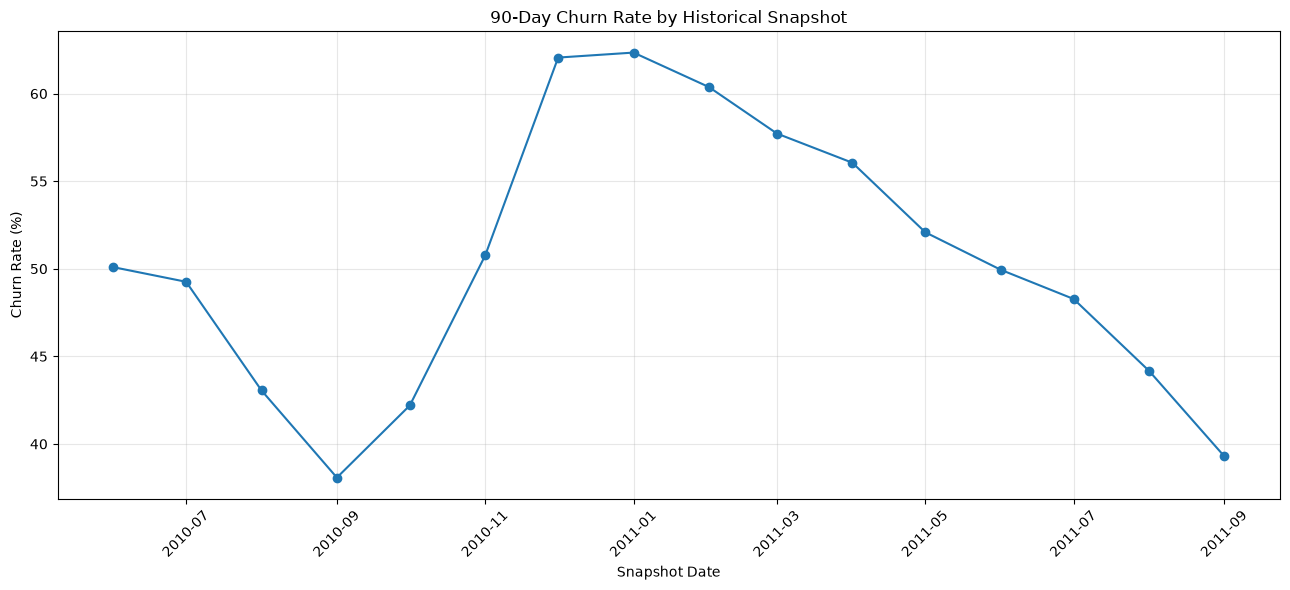

In [13]:
plt.figure(figsize=(13, 6))

plt.plot(
    snapshot_summary["snapshot_date"],
    snapshot_summary["churn_rate_pct"],
    marker="o",
)

plt.title(
    "90-Day Churn Rate by Historical Snapshot"
)

plt.xlabel("Snapshot Date")
plt.ylabel("Churn Rate (%)")

plt.xticks(
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_rate_by_snapshot.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [14]:
display(
    churn_data.head(20)
)

,customer_id,first_purchase,last_purchase,frequency,monetary,total_units,unique_products,recency_days,customer_age_days,tenure_days,average_order_value,average_days_between_orders,purchase_rate_per_90d,last_30d_orders,last_30d_revenue,last_30d_units,last_90d_orders,last_90d_revenue,last_90d_units,previous_90d_orders,previous_90d_revenue,previous_90d_units,eligibility_orders,eligibility_revenue,eligibility_units,orders_change_90d,revenue_change_90d,revenue_change_ratio_90d,total_activity_invoices,return_invoices,return_invoice_rate,return_invoices_last_90d,future_orders_90d,future_revenue_90d,churn_90d,snapshot_date,prediction_end_date
0,12346,2009-12-14 08:34:00,2010-03-02 13:08:00,10,230.550,51,7,90,168,78,23.055,8.667,5.357,0.000,0.000,0.000,0.000,0.000,0.000,10.000,230.550,51.000,10.000,230.550,51.000,-10.000,-230.550,-0.996,11,1,0.091,0,1.000,142.310,0,2010-06-01,2010-08-30
1,12349,2010-04-29 13:20:00,2010-05-18 09:57:00,2,"1,268.520",474,47,13,32,18,634.260,18.000,5.625,1.000,200.000,1.000,2.000,"1,268.520",474.000,0.000,0.000,0.000,2.000,"1,268.520",474.000,2.000,"1,268.520","1,268.520",3,1,0.333,0,0.000,0.000,1,2010-06-01,2010-08-30
2,12355,2010-05-21 11:59:00,2010-05-21 11:59:00,1,488.210,303,22,10,10,0,488.210,10.000,9.000,1.000,488.210,303.000,1.000,488.210,303.000,0.000,0.000,0.000,1.000,488.210,303.000,1.000,488.210,488.210,1,0,0.000,0,0.000,0.000,1,2010-06-01,2010-08-30
3,12358,2009-12-08 07:59:00,2009-12-08 07:59:00,1,"1,429.830",309,17,174,174,0,"1,429.830",174.000,0.517,0.000,0.000,0.000,0.000,0.000,0.000,1.000,"1,429.830",309.000,1.000,"1,429.830",309.000,-1.000,"-1,429.830",-0.999,1,0,0.000,0,1.000,268.100,0,2010-06-01,2010-08-30
4,12359,2009-12-05 13:32:00,2010-03-23 08:55:00,4,"1,522.230",777,65,69,177,107,380.558,35.667,2.034,0.000,0.000,0.000,2.000,683.340,168.000,2.000,838.890,609.000,4.000,"1,522.230",777.000,0.000,-155.550,-0.185,6,2,0.333,1,1.000,489.800,0,2010-06-01,2010-08-30
5,12360,2010-02-22 09:32:00,2010-05-25 09:55:00,3,780.040,756,44,6,98,92,260.013,46.000,2.755,1.000,622.040,655.000,2.000,662.040,656.000,1.000,118.000,100.000,3.000,780.040,756.000,1.000,544.040,4.572,4,1,0.250,1,0.000,0.000,1,2010-06-01,2010-08-30
6,12361,2010-01-26 14:37:00,2010-05-09 15:33:00,2,207.350,83,11,22,125,103,103.675,103.000,1.440,1.000,98.150,38.000,1.000,98.150,38.000,1.000,109.200,45.000,2.000,207.350,83.000,0.000,-11.050,-0.100,2,0,0.000,0,0.000,0.000,1,2010-06-01,2010-08-30
7,12366,2010-03-16 10:28:00,2010-03-16 10:28:00,1,500.240,296,3,76,76,0,500.240,76.000,1.184,0.000,0.000,0.000,1.000,500.240,296.000,0.000,0.000,0.000,1.000,500.240,296.000,1.000,500.240,500.240,1,0,0.000,0,0.000,0.000,1,2010-06-01,2010-08-30
8,12368,2010-03-21 15:56:00,2010-03-21 15:56:00,1,917.700,330,18,71,71,0,917.700,71.000,1.268,0.000,0.000,0.000,1.000,917.700,330.000,0.000,0.000,0.000,1.000,917.700,330.000,1.000,917.700,917.700,1,0,0.000,0,0.000,0.000,1,2010-06-01,2010-08-30
9,12369,2010-03-08 08:09:00,2010-03-08 08:09:00,1,348.320,209,9,84,84,0,348.320,84.000,1.071,0.000,0.000,0.000,1.000,348.320,209.000,0.000,0.000,0.000,1.000,348.320,209.000,1.000,348.320,348.320,1,0,0.000,0,0.000,0.000,1,2010-06-01,2010-08-30


In [15]:
display(
    churn_data[
        [
            "recency_days",
            "frequency",
            "monetary",
            "average_order_value",
            "average_days_between_orders",
            "last_30d_orders",
            "last_90d_orders",
            "previous_90d_orders",
            "orders_change_90d",
            "return_invoice_rate",
            "future_orders_90d",
            "churn_90d",
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
recency_days,"48,079.000",64.720,50.565,0.000,21.000,52.000,103.000,179.000
frequency,"48,079.000",5.734,10.423,1.000,2.000,3.000,6.000,311.000
monetary,"48,079.000","2,700.313","11,370.766",1.300,384.560,931.500,"2,228.045","479,701.580"
average_order_value,"48,079.000",385.495,479.222,1.300,189.344,297.707,434.813,"14,844.767"
average_days_between_orders,"48,079.000",74.223,62.600,0.000,30.914,57.200,102.000,611.000
last_30d_orders,"48,079.000",0.492,1.050,0.000,0.000,0.000,1.000,50.000
last_90d_orders,"48,079.000",1.493,2.545,0.000,0.000,1.000,2.000,97.000
previous_90d_orders,"48,079.000",1.466,2.534,0.000,0.000,1.000,2.000,97.000
orders_change_90d,"48,079.000",0.027,2.149,-76.000,-1.000,0.000,1.000,66.000
return_invoice_rate,"48,079.000",0.130,0.171,0.000,0.000,0.000,0.250,0.833


In [16]:
churn_data.to_parquet(
    OUTPUT_PATH,
    index=False,
)


snapshot_summary.to_csv(
    REPORTS_DIR
    / "churn_snapshot_summary.csv",
    index=False,
)


churn_dataset_summary = {
    "prediction_days": PREDICTION_DAYS,
    "eligibility_days": ELIGIBILITY_DAYS,
    "snapshot_rows": int(len(churn_data)),
    "unique_customers": int(
        churn_data["customer_id"].nunique()
    ),
    "snapshots": int(
        churn_data["snapshot_date"].nunique()
    ),
    "churn_observations": int(
        churn_data["churn_90d"].sum()
    ),
    "overall_churn_rate": float(
        churn_data["churn_90d"].mean()
    ),
    "first_snapshot": str(
        churn_data["snapshot_date"].min()
    ),
    "last_snapshot": str(
        churn_data["snapshot_date"].max()
    ),
}


(
    REPORTS_DIR
    / "churn_dataset_summary.json"
).write_text(
    json.dumps(
        churn_dataset_summary,
        indent=2,
    ),
    encoding="utf-8",
)


print("=" * 65)
print("Temporal churn dataset created successfully")
print("=" * 65)

print(f"Rows:             {len(churn_data):,}")
print(
    f"Unique customers: "
    f"{churn_data['customer_id'].nunique():,}"
)
print(
    f"Snapshots:        "
    f"{churn_data['snapshot_date'].nunique():,}"
)
print(
    f"Churn rate:       "
    f"{churn_data['churn_90d'].mean() * 100:.2f}%"
)
print(f"Saved to:         {OUTPUT_PATH}")

Temporal churn dataset created successfully
Rows:             48,079
Unique customers: 5,236
Snapshots:        16
Churn rate:       50.94%
Saved to:         c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\churn_snapshots.parquet


## Churn Dataset Findings

### The 90-day churn definition produces a useful prediction target

The final temporal dataset contains 48,079 point-in-time customer observations
across 16 historical snapshots and 5,236 unique customers.

Approximately 50.94% of snapshot observations are classified as churn, while
49.06% result in a future purchase.

This relatively balanced target is suitable for predictive modeling and avoids
the extreme class imbalance commonly encountered in churn problems.

### Churn exhibits a strong temporal pattern

Churn rates vary meaningfully across historical snapshots, ranging from
approximately 38% to 62%.

The pattern is also remarkably consistent across comparable months in the two
years represented in the dataset.

For example:

- June 2010: 50.09% vs June 2011: 49.94%
- July 2010: 49.26% vs July 2011: 48.28%
- August 2010: 43.06% vs August 2011: 44.17%
- September 2010: 38.08% vs September 2011: 39.29%

This suggests that customer return behavior contains a meaningful seasonal
component that should be considered during modeling.

### Winter snapshots show substantially higher churn

The highest observed churn rates occur around December, January, and February,
where the 90-day churn rate exceeds 60%.

This seasonal variation means that model evaluation must preserve chronological
order rather than randomly mixing historical observations.

### Multiple snapshots create a realistic point-in-time prediction dataset

The same customer may appear at several historical snapshot dates, but every
observation represents a different prediction decision made using only
information available at that point in time.

This substantially increases the number of useful training observations while
preserving the temporal nature of the business problem.

### Random train-test splitting will not be used

Random splitting could place observations from the same customer and overlapping
prediction periods into both training and evaluation datasets.

The modeling stage will therefore use chronological train, validation, and test
periods with temporal gaps between them to reduce leakage from overlapping
90-day prediction windows.